In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy.stats import f
from scipy.stats import norm

In [16]:
class Regressor:
    def __init__(self, X: np.ndarray, y: np.ndarray, functions: list["function"], precise: float = 3, beta: float = 0.05) -> None:
        self.X = X
        self.y = y
        self.functions = functions
        self.beta = beta
        self.psi_matrix = np.array([[f(val) for f in self.functions] for val in self.X])
        self.F_inverted = self.findFInvertedMatrix()
        self.beta_estimations = self.findRegressionCoefficients()
        self.precise = precise

    def findFInvertedMatrix(self) -> np.ndarray:
        F_matrix = self.psi_matrix.T @ self.psi_matrix
        F_inverted_matrix = np.linalg.inv(F_matrix)

        return F_inverted_matrix

    def findRegressionCoefficients(self) -> np.ndarray:
        F_matrix = self.psi_matrix.T @ self.psi_matrix
        F_inverted_matrix = np.linalg.inv(F_matrix)
        beta_estimations = F_inverted_matrix @ self.psi_matrix.T @ self.y

        return beta_estimations
    
    def findErrors(self) -> np.ndarray:
        self.beta_estimations = self.findRegressionCoefficients()
        y_hat = self.psi_matrix @ self.beta_estimations
        return self.y - y_hat
    
    def findRSS(self) -> float:
        errors = self.findErrors()
        return errors.T @ errors
    
    def findTSS(self) -> float:
        y_avg = np.average(self.y)
        return np.sum((y_avg - self.y) ** 2)
    
    def findRSquare(self) -> float:
        TSS = self.findTSS()
        RSS = self.findRSS()
        return np.round((TSS - RSS) / TSS, self.precise)
    
    def checkCoefficientSignificance(self, ind: int) -> float:
        RSS = self.findRSS()
        F_inverted_i_i = self.F_inverted[ind, ind]
        beta_estimated = self.beta_estimations[ind]
        n = self.X.shape[0]
        p = len(self.functions)
        delta_estimation = abs(beta_estimated / np.sqrt(RSS * F_inverted_i_i / (n - p)))
        p_value = t.cdf(-delta_estimation, n - p) + t.sf(delta_estimation, n - p)
        return p_value
    
    def compareCoefficients(self, i: int, j: int) -> float:
        RSS = self.findRSS()
        F_inverted_i_i = self.F_inverted[i, i]
        F_inverted_j_j = self.F_inverted[j, j]
        beta_estimated_i = self.beta_estimations[i]
        beta_estimated_j = self.beta_estimations[j]
        n = self.X.shape[0]
        p = len(self.functions)
        delta_estimation = abs((beta_estimated_i - beta_estimated_j) / np.sqrt(RSS * (F_inverted_i_i + F_inverted_j_j) / (n - p)))
        p_value = t.cdf(-delta_estimation, n - p) + t.sf(delta_estimation, n - p)
        return p_value
    
    def findConfidenceInterval(self, point: np.ndarray) -> tuple[float]:
        prediction = self.getPrediction(point)
        n = self.X.shape[0]
        p = len(self.functions)
        RSS = self.findRSS()
        func_vals = np.array([func(point) for func in self.functions])
        val = np.sqrt(RSS * (1 + func_vals @ self.F_inverted @ func_vals.T) / (n - p))
        left_bound = (1 - self.beta) / 2
        right_bound = (1 + self.beta) / 2
        left_percentile = t.ppf(left_bound, n - p)
        right_percentile = t.ppf(right_bound, n - p)

        left_value = prediction - val * right_percentile
        right_value = prediction - val * left_percentile

        return (left_value, right_value)

    def getPrediction(self, point: np.ndarray) -> float:
        func_vals = np.array([func(point) for func in self.functions])
        prediction = self.beta_estimations.T @ func_vals
        return prediction
    
    def setBetaEstimations(self, new_betas: np.ndarray) -> None:
        self.beta_estimations = new_betas
    
    def getPredictions(self, points: np.ndarray) -> np.ndarray:
        predictions = [self.getPrediction(point) for point in points]
        return predictions
    
    def findIndependance(self) -> float:
        errors = self.findErrors()
        n = errors.shape[0]
        inv_count = 0
        for i in range(n):
            for j in range(i + 1, n):
                if (errors[j] < errors[i]):
                    inv_count += 1
        
        middle_inv_count = n * (n - 1) // 4

        delta = abs((inv_count - middle_inv_count) / np.sqrt(n ** 3 / 36))
        p_value = norm.cdf(-delta) + norm.sf(delta)
        return p_value
    
    def printRegr(self) -> None:
        answ = ""
        for i in range(0, self.beta_estimations.shape[0]):
            coef = self.beta_estimations[i]
            answ += f" + {str(np.round(coef, self.precise))}*x_{i}"
        print("y =", answ)

In [17]:
y = np.array(
    [1, 5, 2]
)

X = np.array(
    [
        [1, 0],
        [0, 1],
        [1, 1]
    ]
)

func0 = lambda x: x[0]
func1 = lambda x: x[1]

funcs = [func0, func1]

In [18]:
regr = Regressor(X, y, funcs)

regr.printRegr()

y =  + -0.333*x_0 + 3.667*x_1


In [19]:
for i in range(len(funcs)):
    print(f"p-value для значимости {i}-ого коэффициента: {regr.checkCoefficientSignificance(i)}")

print(f"R^2 = {regr.findRSquare()}")

p-value для значимости 0-ого коэффициента: 0.8886112459769364
p-value для значимости 1-ого коэффициента: 0.30238803008029175
R^2 = 0.385


In [20]:
def absfunc(betas: np.ndarray) -> float:
    return np.sum(np.abs(betas))

def squarefunc(betas: np.ndarray) -> float:
    return np.sum(betas ** 2)

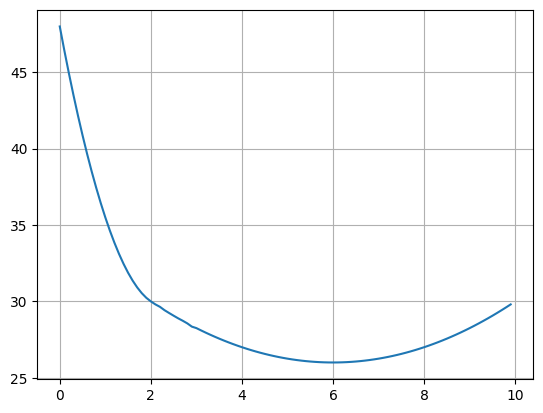

6.0


In [26]:
from scipy.optimize import minimize

def objective(beta, X, y, my_lambda, mfunc):
    error = y - X @ beta
    mse = np.sum(error**2)
    penalty = mfunc(beta)
    
    return mse + my_lambda * penalty

beta_start = np.zeros(X.shape[1])

lambdas = np.arange(0, 10, 0.1)
coeffs = []
cvss_s = []
def calculateCVSS_Correct(X, y, batch_size, lmbda, mfunc):
    n = X.shape[0]
    cvss = 0
    for i in range(n // batch_size):
        cut_from, cut_to = i * batch_size, (i + 1) * batch_size
        rem_X = np.delete(X, slice(cut_from, cut_to), axis=0)
        rem_y = np.delete(y, slice(cut_from, cut_to), axis=0)
        
        test_X = X[cut_from:cut_to]
        test_y = y[cut_from:cut_to]

        beta_start = np.zeros(X.shape[1])
        res = minimize(objective, beta_start, args=(rem_X, rem_y, lmbda, mfunc), method="Nelder-Mead")
        current_beta = res.x
        
        y_estim = test_X @ current_beta
        cvss += np.sum((y_estim - test_y) ** 2)
        
    return cvss

for lmbda in lambdas:
    score = calculateCVSS_Correct(X, y, 1, lmbda, absfunc)
    cvss_s.append(score)


plt.grid()
plt.plot(lambdas, cvss_s)
plt.show()
print(lambdas[np.argmin(cvss_s)])

In [22]:
res = minimize(objective, beta_start, args=(X, y, 5.1, absfunc))
current_beta = res.x
print(current_beta)

[-5.54754179e-10  2.23929823e+00]


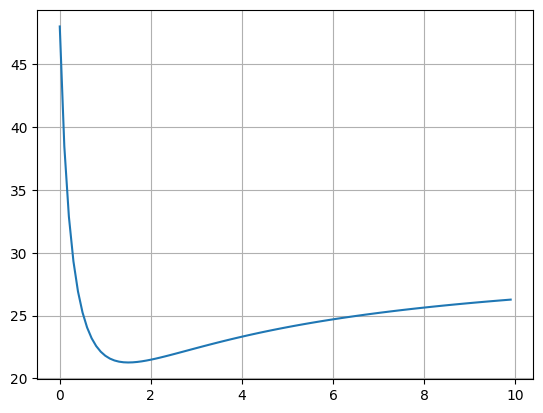

1.5
[0.31111112 1.9111111 ]


In [23]:
cvss_s = []

for lmbda in lambdas:
    score = calculateCVSS_Correct(X, y, 1, lmbda, squarefunc)
    cvss_s.append(score)


plt.grid()
plt.plot(lambdas, cvss_s)
plt.show()
print(lambdas[np.argmin(cvss_s)])
res = minimize(objective, beta_start, args=(X, y, 1.5, squarefunc))
current_beta = res.x
print(current_beta)